In [11]:
import numpy as np
import os

DATASET_PATH = "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"

patient = "sub-strokecase0001"
patient_path = os.path.join(DATASET_PATH, patient)

for file in ["flair.npy", "adc.npy", "dwi.npy", "mask.npy"]:
    data = np.load(os.path.join(patient_path, file))
    print(f"{file}")
    print(f"Shape : {data.shape}")
    print(f"Dtype : {data.dtype}")
    print("-" * 40)

flair.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
adc.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
dwi.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
mask.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------


### Import Libraries

In [12]:
!pip install -q monai nibabel SimpleITK

In [13]:
# installation mlflow
!pip install -q mlflow

In [14]:
# Standard Libraries

import os
import random
from pathlib import Path
import mlflow
import numpy as np
import matplotlib.pyplot as plt

# PyTorch

import torch
from torch.utils.data import Dataset, DataLoader

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# Data Split

from sklearn.model_selection import train_test_split


# MONAI

from monai.networks.nets import UNet

from monai.losses import DiceCELoss

from monai.metrics import (
    DiceMetric,
    MeanIoU
)

from monai.transforms import (
    Compose,
    Activations,
    AsDiscrete
)

from monai.data import decollate_batch
from torch.optim import Adam
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print(f"PyTorch Version : {torch.__version__}")
print(f"MONAI Version   : {__import__('monai').__version__}")
print(f"Device          : {device}")
print("=" * 50)

PyTorch Version : 2.10.0+cu128
MONAI Version   : 1.6.0
Device          : cuda


### Project Configuration

In [16]:
MLFLOW_TRACKING_URI = "https://elated-autistic-subfloor.ngrok-free.dev"  
EXPERIMENT_NAME = "Stroke-Segmentation"

In [17]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    client = mlflow.MlflowClient()
    client.search_experiments()  # ping simple pour tester la connexion
    print(f"Connexion réussie au serveur MLflow : {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"Impossible de se connecter au serveur MLflow ({MLFLOW_TRACKING_URI})")
    print(f"Erreur : {e}")

mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experiment actif : {EXPERIMENT_NAME}")

Connexion réussie au serveur MLflow : https://elated-autistic-subfloor.ngrok-free.dev
Experiment actif : Stroke-Segmentation


In [18]:
# Dataset
DATASET_PATH = Path(
    "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"
)

# General Training Parameters

BATCH_SIZE = 16
NUM_EPOCHS = 100
NUM_WORKERS = 2

# MRI Modalities

MODALITIES = [
    "adc",
    "dwi",
    "flair"
]

NUM_CHANNELS = len(MODALITIES) 

# Hyperparameter Experiments

experiments = [
    {
        "name": "Adam_lr1e3",
        "optimizer": "Adam",
        "lr": 1e-3
    },
    {
        "name": "Adam_lr5e4",
        "optimizer": "Adam",
        "lr": 5e-4
    }
]

# Device

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Save Directory

SAVE_DIR = Path("/kaggle/working/models/unet2d_multimodal")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Display Configuration

print("=" * 60)
print("U-Net 2D Multimodal - Project Configuration")
print("=" * 60)

print(f"Dataset Path : {DATASET_PATH}")
print(f"Modalities   : {', '.join(m.upper() for m in MODALITIES)}")
print(f"Channels     : {NUM_CHANNELS}")
print(f"Device       : {DEVICE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Workers      : {NUM_WORKERS}")
print(f"Experiments  : {len(experiments)}")
print(f"Save Dir     : {SAVE_DIR}")

print("=" * 60)

for exp in experiments:
    print(f"{exp['name']} | LR = {exp['lr']}")

U-Net 2D Multimodal - Project Configuration
Dataset Path : /kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed
Modalities   : ADC, DWI, FLAIR
Channels     : 3
Device       : cuda
Batch Size   : 16
Epochs       : 100
Workers      : 2
Experiments  : 2
Save Dir     : /kaggle/working/models/unet2d_multimodal
Adam_lr1e3 | LR = 0.001
Adam_lr5e4 | LR = 0.0005


### Train / Validation / Test Split

In [19]:
# Get all patient folders
patients = sorted(
    [
        patient.name
        for patient in DATASET_PATH.iterdir()
        if patient.is_dir()
    ]
)

print(f"Total Patients : {len(patients)}")

# Split Dataset

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

# Convert patient names to full paths

train_patients = [DATASET_PATH / p for p in train_patients]
val_patients = [DATASET_PATH / p for p in val_patients]
test_patients = [DATASET_PATH / p for p in test_patients]

# Display Dataset Statistics

print("\nDataset Split")
print("-" * 40)

print(
    f"Train      : {len(train_patients):3d} patients "
    f"({len(train_patients)/len(patients)*100:.1f}%)"
)

print(
    f"Validation : {len(val_patients):3d} patients "
    f"({len(val_patients)/len(patients)*100:.1f}%)"
)

print(
    f"Test       : {len(test_patients):3d} patients "
    f"({len(test_patients)/len(patients)*100:.1f}%)"
)

Total Patients : 240

Dataset Split
----------------------------------------
Train      : 168 patients (70.0%)
Validation :  36 patients (15.0%)
Test       :  36 patients (15.0%)


# Experiment 1: 2D U-Net for Stroke Lesion Segmentation Using the multi-Modality

### Création du StrokeDataset

In [20]:
class StrokeDataset2D(Dataset):

    def __init__(self, patient_dirs, transform=None):

        self.samples = []
        self.transform = transform

        for patient_dir in patient_dirs:

            # Load one modality only to get the number of slices
            adc = np.load(
                patient_dir / "adc.npy",
                mmap_mode="r"
            )

            num_slices = adc.shape[-1]

            for slice_idx in range(num_slices):

                self.samples.append(
                    (patient_dir, slice_idx)
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        patient_dir, slice_idx = self.samples[index]


        adc = np.load(
            patient_dir / "adc.npy",
            mmap_mode="r"
        ).astype(np.float32)

        dwi = np.load(
            patient_dir / "dwi.npy",
            mmap_mode="r"
        ).astype(np.float32)

        flair = np.load(
            patient_dir / "flair.npy",
            mmap_mode="r"
        ).astype(np.float32)

        mask = np.load(
            patient_dir / "mask.npy",
            mmap_mode="r"
        ).astype(np.float32)


        adc_slice = adc[:, :, slice_idx]
        dwi_slice = dwi[:, :, slice_idx]
        flair_slice = flair[:, :, slice_idx]

        target = mask[:, :, slice_idx]
        # Z-score normalization

        def normalize(image):

            mean = image.mean()
            std = image.std()

            if std > 0:
                image = (image - mean) / std

            return image

        adc_slice = normalize(adc_slice)
        dwi_slice = normalize(dwi_slice)
        flair_slice = normalize(flair_slice)

        image = np.stack(
            [
                adc_slice,
                dwi_slice,
                flair_slice
            ],
            axis=0
        )

        # Mask: (H, W) -> (1, H, W)

        target = np.expand_dims(
            target,
            axis=0
        )

        # Convert to PyTorch tensors

        image = torch.from_numpy(image).float()
        target = torch.from_numpy(target).float()

        # Data augmentation

        if self.transform is not None:

            data = {
                "image": image,
                "mask": target
            }

            data = self.transform(data)

            image = data["image"]
            target = data["mask"]

        return image, target

### data augmentation

In [21]:
from monai.transforms import (
    Compose,
    RandFlipd,
    RandRotate90d
)

train_transform = Compose([

    # Random horizontal flip
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=0
    ),

    # Random vertical flip
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=1
    ),

    # Random 90-degree rotation
    RandRotate90d(
        keys=["image", "mask"],
        prob=0.5,
        max_k=3
    )
])

print("Training data augmentation configured.")

Training data augmentation configured.


### Créer les DataLoader

In [22]:
train_dataset = StrokeDataset2D(
    train_patients,
    transform=train_transform
)

val_dataset = StrokeDataset2D(
    val_patients,
    transform=None
)

test_dataset = StrokeDataset2D(
    test_patients,
    transform=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

print(f"Training slices   : {len(train_dataset)}")
print(f"Validation slices : {len(val_dataset)}")
print(f"Test slices       : {len(test_dataset)}")

print()

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

print("=" * 60)

images, masks = next(iter(train_loader))

print(f"Input shape : {images.shape}")
print(f"Mask shape  : {masks.shape}")

print("=" * 60)

Dataset Statistics
Training slices   : 10752
Validation slices : 2304
Test slices       : 2304

Train batches      : 672
Validation batches : 144
Test batches       : 144
Input shape : torch.Size([16, 3, 128, 128])
Mask shape  : torch.Size([16, 1, 128, 128])


### Définir la Loss et l'Optimizer et Hyperparameters

In [23]:
# Loss Function

loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean",
    lambda_ce=0.5,
    lambda_dice=1.5
)

# Evaluation Metrics

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

iou_metric = MeanIoU(
    include_background=False,
    reduction="mean"
)

# Display Configuration

print("=" * 60)
print("Loss Function and Evaluation Metrics")
print("=" * 60)

print("\nLoss Function")
print(loss_function)

print("\nEvaluation Metrics")
print("- Dice Score")
print("- Mean IoU")

print("\nInput Modalities")
for i, modality in enumerate(MODALITIES):
    print(f"- Channel {i}: {modality.upper()}")

print("=" * 60)

Loss Function and Evaluation Metrics

Loss Function
DiceCELoss(
  (dice): DiceLoss()
  (cross_entropy): CrossEntropyLoss()
  (binary_cross_entropy): BCEWithLogitsLoss()
)

Evaluation Metrics
- Dice Score
- Mean IoU

Input Modalities
- Channel 0: ADC
- Channel 1: DWI
- Channel 2: FLAIR


In [24]:
post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5)
])

### Fonction d'entraînement

In [25]:
def train_one_epoch(model, train_loader, optimizer, loss_function, device):

    model.train()

    running_loss = 0.0

    for images, masks in train_loader:

        # Move data to device
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = loss_function(outputs, masks)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

    # Average loss over all batches
    epoch_loss = running_loss / len(train_loader)

    return epoch_loss

### Fonction de validation

In [26]:
from monai.data import decollate_batch

def validate(model, val_loader, dice_metric, iou_metric, post_pred, device):

    model.eval()

    dice_metric.reset()
    iou_metric.reset()

    with torch.no_grad():

        for images, masks in val_loader:

            # Move batch to device
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            # Forward pass
            outputs = model(images)

            # Post-processing
            outputs = [post_pred(pred) for pred in decollate_batch(outputs)]
            masks = decollate_batch(masks)

            # Update metrics
            dice_metric(y_pred=outputs, y=masks)
            iou_metric(y_pred=outputs, y=masks)

    dice = dice_metric.aggregate().item()
    iou = iou_metric.aggregate().item()

    dice_metric.reset()
    iou_metric.reset()

    return dice, iou


Experiment: MULTIMODAL-2D_Adam_lr1e3
Epoch [001/100] | Loss: 1.7827 | Dice: 0.3820 | IoU: 0.2763
Epoch [002/100] | Loss: 1.5370 | Dice: 0.5218 | IoU: 0.4179
Epoch [003/100] | Loss: 1.2367 | Dice: 0.5826 | IoU: 0.4687
Epoch [004/100] | Loss: 1.2124 | Dice: 0.6014 | IoU: 0.4883
Epoch [005/100] | Loss: 1.2007 | Dice: 0.6080 | IoU: 0.4939
Epoch [006/100] | Loss: 1.1963 | Dice: 0.6123 | IoU: 0.4955
Epoch [007/100] | Loss: 1.1908 | Dice: 0.6323 | IoU: 0.5130
Epoch [008/100] | Loss: 1.1886 | Dice: 0.6312 | IoU: 0.5148
Epoch [009/100] | Loss: 1.1859 | Dice: 0.6371 | IoU: 0.5180
Epoch [010/100] | Loss: 1.1827 | Dice: 0.6360 | IoU: 0.5226
Epoch [011/100] | Loss: 1.1797 | Dice: 0.6326 | IoU: 0.5185
Epoch [012/100] | Loss: 1.1800 | Dice: 0.6397 | IoU: 0.5212
Epoch [013/100] | Loss: 1.1776 | Dice: 0.6265 | IoU: 0.5110
Epoch [014/100] | Loss: 1.1753 | Dice: 0.6384 | IoU: 0.5211
Epoch [015/100] | Loss: 1.1379 | Dice: 0.0000 | IoU: 0.0000
Epoch [016/100] | Loss: 0.5163 | Dice: 0.0000 | IoU: 0.0000
Ep

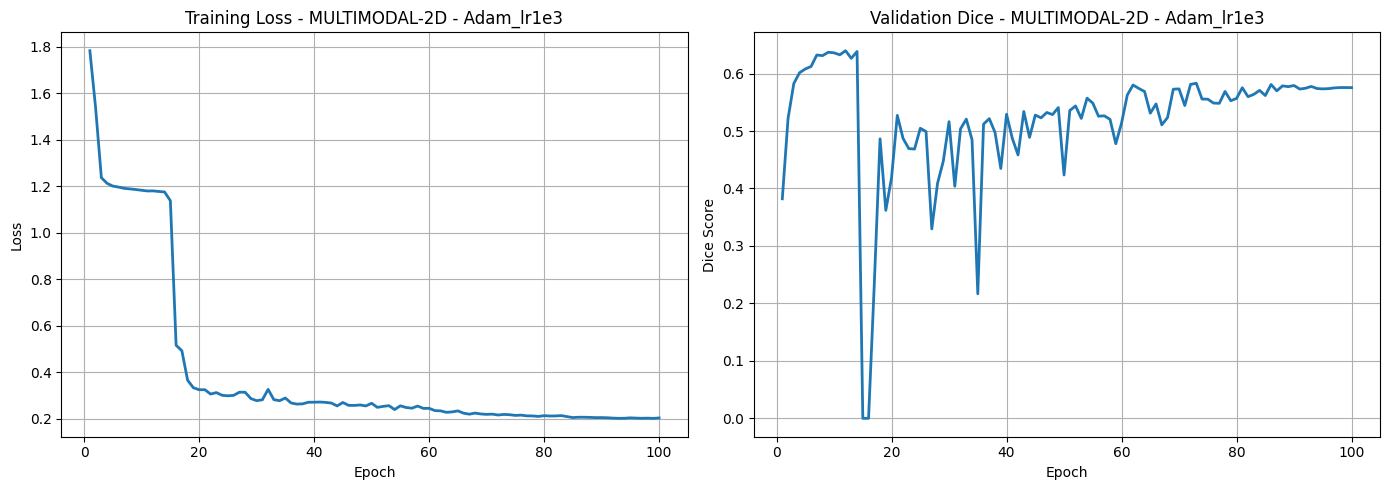

🏃 View run MULTIMODAL-2D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/1c5860950e194d9c8a156f1d678961fd
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

Experiment: MULTIMODAL-2D_Adam_lr5e4
Epoch [001/100] | Loss: 1.7463 | Dice: 0.3735 | IoU: 0.2682
Epoch [002/100] | Loss: 1.6530 | Dice: 0.3760 | IoU: 0.2716
Epoch [003/100] | Loss: 1.4396 | Dice: 0.5604 | IoU: 0.4493
Epoch [004/100] | Loss: 1.2460 | Dice: 0.5673 | IoU: 0.4513
Epoch [005/100] | Loss: 1.2106 | Dice: 0.6111 | IoU: 0.4953
Epoch [006/100] | Loss: 1.2006 | Dice: 0.6065 | IoU: 0.4868
Epoch [007/100] | Loss: 1.1923 | Dice: 0.6181 | IoU: 0.5014
Epoch [008/100] | Loss: 1.1883 | Dice: 0.6275 | IoU: 0.5128
Epoch [009/100] | Loss: 1.1847 | Dice: 0.6400 | IoU: 0.5222
Epoch [010/100] | Loss: 1.1822 | Dice: 0.6297 | IoU: 0.5109
Epoch [011/100] | Loss: 1.1802 | Dice: 0.6232 | IoU: 0.5049
Epoch [012/100] | Loss: 1.1759 | Dice: 0.6391 | IoU: 0.5236
Epoch [013/100

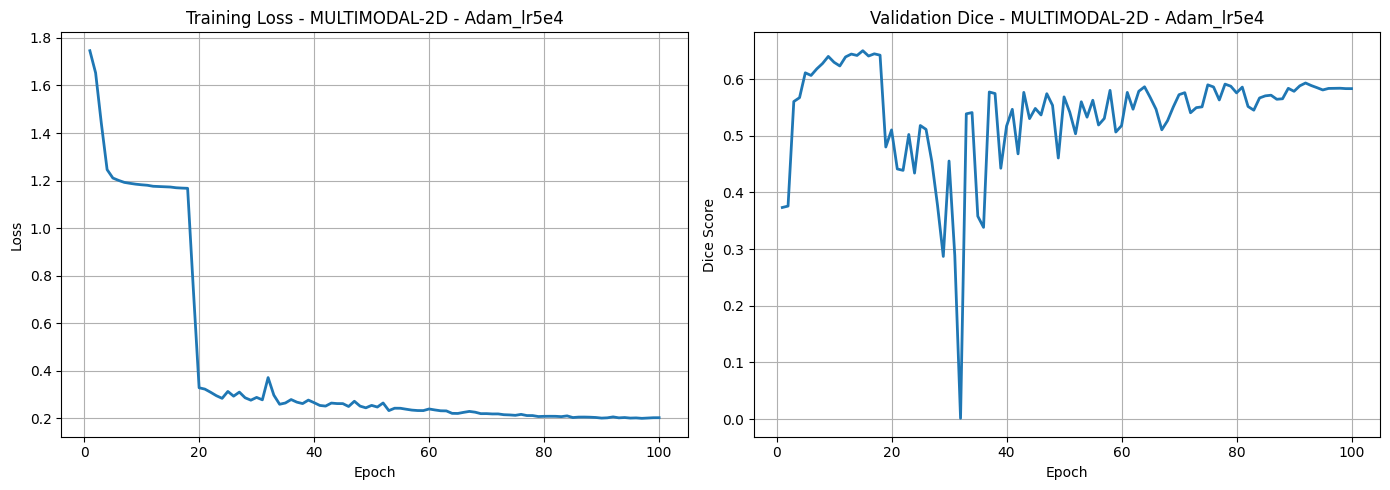

🏃 View run MULTIMODAL-2D_Adam_lr5e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f839658b7d7945449f8b8fe0dcc07ea1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

MLflow Training completed successfully.


In [27]:
# ============================================================
# MLflow Training - U-Net 2D Multimodal
# Modalities: ADC + DWI + FLAIR
# ============================================================

results = []

# ============================================================
# Directory to save multimodal models
# ============================================================

MULTIMODAL_SAVE_DIR = SAVE_DIR / "multimodal"

MULTIMODAL_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# Training Experiments
# ============================================================

for exp in experiments:

    print("\n" + "=" * 60)
    print(f"Experiment: MULTIMODAL-2D_{exp['name']}")
    print("=" * 60)

    # ========================================================
    # Start MLflow Run
    # ========================================================

    with mlflow.start_run(
        run_name=f"MULTIMODAL-2D_{exp['name']}"
    ) as run:

        # MLflow Tags
        mlflow.set_tag("experiment_group","MULTIMODAL-2D")
        mlflow.set_tag("modality","ADC+DWI+FLAIR" )
        mlflow.set_tag("dimension","2D")
        mlflow.set_tag("dataset","ISLES2022")

        mlflow.set_tag("framework","PyTorch + MONAI" )

        # MLflow Parameters

        mlflow.log_param( "architecture","2D U-Net")
        mlflow.log_param( "model","2D_UNet")
        mlflow.log_param("modality","ADC+DWI+FLAIR" )
        mlflow.log_param("dimension","2D")
        mlflow.log_param("optimizer", exp["optimizer"] )
        mlflow.log_param("learning_rate", exp["lr"])
        mlflow.log_param("batch_size", BATCH_SIZE )
        mlflow.log_param("epochs", NUM_EPOCHS)
        mlflow.log_param("num_workers", NUM_WORKERS)
        mlflow.log_param("num_channels", NUM_CHANNELS) 
        mlflow.log_param("input_modalities", "ADC,DWI,FLAIR")
        mlflow.log_param("channels", str((16, 32, 64, 128, 256)))
        mlflow.log_param("strides", str((2, 2, 2, 2)) )
        mlflow.log_param("num_res_units", 2)
        mlflow.log_param( "scheduler","CosineAnnealingLR")
        mlflow.log_param("loss_function","DiceCELoss")
        mlflow.log_param( "lambda_dice", 1.5)
        mlflow.log_param("lambda_ce", 0.5 )

        # Create 2D U-Net
        model = UNet(
            spatial_dims=2,
            in_channels=NUM_CHANNELS,
            out_channels=1,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2
        ).to(DEVICE)

        # Optimizer
        optimizer = Adam(
            model.parameters(),
            lr=exp["lr"]
        )

        # Learning Rate Scheduler

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS
        )

        # Best Model Tracking

        best_dice = 0.0
        best_iou = 0.0
        best_epoch = 0

        train_losses = []
        val_dices = []
        val_ious = []

        # Model Path
        model_path = (
            MULTIMODAL_SAVE_DIR
            / f"best_model_{exp['name']}.pth"
        )

        # Training Loop
        for epoch in range(NUM_EPOCHS):

            # Training
            epoch_loss = train_one_epoch(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                loss_function=loss_function,
                device=DEVICE
            )

            train_losses.append(epoch_loss)

            # Validation
            dice, iou = validate(
                model=model,
                val_loader=val_loader,
                dice_metric=dice_metric,
                iou_metric=iou_metric,
                post_pred=post_pred,
                device=DEVICE
            )

            val_dices.append(dice)
            val_ious.append(iou)

            # Scheduler
            scheduler.step()

            # Log Metrics Every Epoch
            mlflow.log_metric("train_loss", epoch_loss,step=epoch + 1 )
            mlflow.log_metric("val_dice",dice,step=epoch + 1)
            mlflow.log_metric( "val_iou", iou, step=epoch + 1)

            # ------------------------------------------------
            # Save Best Model
            # ------------------------------------------------

            if dice > best_dice:

                best_dice = dice
                best_iou = iou
                best_epoch = epoch + 1

                torch.save(
                    model.state_dict(),
                    model_path
                )

            # Display Epoch Results

            print(
                f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] "
                f"| Loss: {epoch_loss:.4f} "
                f"| Dice: {dice:.4f} "
                f"| IoU: {iou:.4f}"
            )

        # Log Best Metrics
        mlflow.log_metric("best_dice",best_dice )
        mlflow.log_metric("best_iou", best_iou )
        mlflow.log_metric("best_epoch", best_epoch )

        # Log Best Model

        mlflow.log_artifact(str(model_path),artifact_path="model")
        curve_path = (MULTIMODAL_SAVE_DIR / f"training_curves_{exp['name']}.png" )

        plt.figure(figsize=(14, 5))

        # Training Loss

        plt.subplot(1, 2, 1)

        plt.plot(
            range(
                1,
                NUM_EPOCHS + 1
            ),
            train_losses,
            linewidth=2
        )

        plt.title(
            f"Training Loss - MULTIMODAL-2D - {exp['name']}"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)

        # Validation Dice

        plt.subplot(1, 2, 2)

        plt.plot(
            range(
                1,
                NUM_EPOCHS + 1
            ),
            val_dices,
            linewidth=2
        )

        plt.title(
            f"Validation Dice - MULTIMODAL-2D - {exp['name']}"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Dice Score")
        plt.grid(True)

        plt.tight_layout()

        plt.savefig(
            curve_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()

        # Log Training Curves
        mlflow.log_artifact(
            str(curve_path),
            artifact_path="plots"
        )

        # Store Experiment Results
        results.append({
            "Experiment": exp["name"],
            "Run Name": f"MULTIMODAL-2D_{exp['name']}",
            "Run ID": run.info.run_id,
            "Learning Rate": exp["lr"],
            "Best Dice": best_dice,
            "Best IoU": best_iou,
            "Best Epoch": best_epoch,
            "Train Loss": train_losses,
            "Validation Dice": val_dices,
            "Validation IoU": val_ious,
            "Model Path": str(model_path)
        })


print("\n" + "=" * 60)
print("MLflow Training completed successfully.")
print("=" * 60)

In [28]:
import pandas as pd

# Create DataFrame from experiment results
df_results = pd.DataFrame(results)

# Sort experiments by best validation Dice
df_results = df_results.sort_values(
    by="Best Dice",
    ascending=False
).reset_index(drop=True)

# Select relevant columns
comparison_table = df_results[
    [
        "Run Name",
        "Learning Rate",
        "Best Dice",
        "Best IoU",
        "Best Epoch",
        "Run ID",
        "Model Path"
    ]
]

print("=" * 80)
print("Comparison of MULTIMODAL-2D Experiments")
print("=" * 80)

display(comparison_table)

Comparison of MULTIMODAL-2D Experiments


,Run Name,Learning Rate,Best Dice,Best IoU,Best Epoch,Run ID,Model Path
0,MULTIMODAL-2D_Adam_lr5e4,0.0005,0.650100,0.531969,15,f839658b7d7945449f8b8fe0dcc07ea1,/kaggle/working/models/unet2d_multimodal/multi...
1,MULTIMODAL-2D_Adam_lr1e3,0.0010,0.639731,0.521189,12,1c5860950e194d9c8a156f1d678961fd,/kaggle/working/models/unet2d_multimodal/multi...


### Tracer les courbes de Loss et du Dice

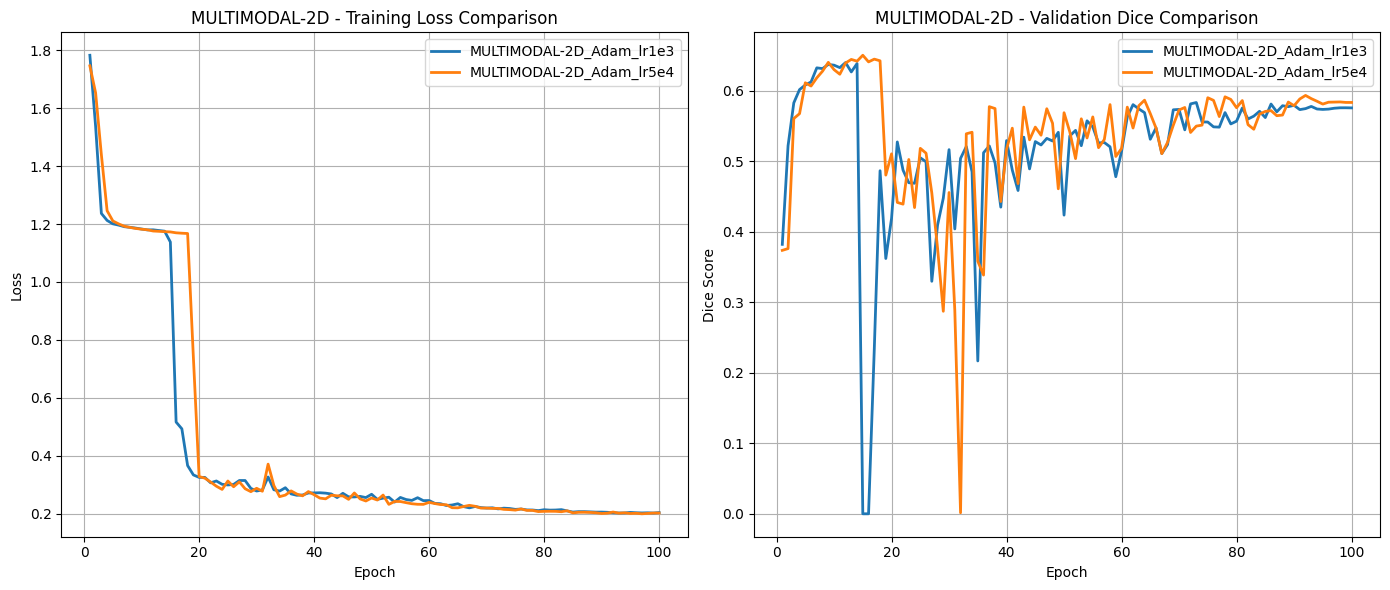

Comparison curves saved to: /kaggle/working/models/unet2d_multimodal/multimodal/comparison_training_curves.png


In [29]:
plt.figure(figsize=(14, 6))

# Training Loss Comparison
plt.subplot(1, 2, 1)

for result in results:

    epochs = range(
        1,
        len(result["Train Loss"]) + 1
    )

    plt.plot(
        epochs,
        result["Train Loss"],
        label=result["Run Name"],
        linewidth=2
    )

plt.title(
    "MULTIMODAL-2D - Training Loss Comparison"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

# Validation Dice Comparison
plt.subplot(1, 2, 2)

for result in results:

    epochs = range(
        1,
        len(result["Validation Dice"]) + 1
    )

    plt.plot(
        epochs,
        result["Validation Dice"],
        label=result["Run Name"],
        linewidth=2
    )

plt.title(
    "MULTIMODAL-2D - Validation Dice Comparison"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")

plt.legend()
plt.grid(True)

plt.tight_layout()

# Save Comparison Figure
comparison_curve_path = (
    MULTIMODAL_SAVE_DIR
    / "comparison_training_curves.png"
)

plt.savefig(
    comparison_curve_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"Comparison curves saved to: "
    f"{comparison_curve_path}"
)

### Load the Best Model

In [30]:
best_result = max(
    results,
    key=lambda x: x["Best Dice"]
)

print("=" * 60)
print("Best MULTIMODAL-2D Experiment")
print("=" * 60)

print(
    f"Run Name   : "
    f"{best_result['Run Name']}"
)

print(
    f"Experiment : "
    f"{best_result['Experiment']}"
)

print(
    f"Best Dice  : "
    f"{best_result['Best Dice']:.4f}"
)

print(
    f"Best IoU   : "
    f"{best_result['Best IoU']:.4f}"
)

print(
    f"Best Epoch : "
    f"{best_result['Best Epoch']}"
)

print(
    f"Run ID     : "
    f"{best_result['Run ID']}"
)

print("=" * 60)

# Create Best Model Architecture
model = UNet(
    spatial_dims=2,
    in_channels=NUM_CHANNELS,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2
).to(DEVICE)

# Load Best Model Weights
model.load_state_dict(
    torch.load(
        best_result["Model Path"],
        map_location=DEVICE
    )
)

# Evaluation mode
model.eval()

print(
    f"Best model loaded successfully on {DEVICE}."
)

Best MULTIMODAL-2D Experiment
Run Name   : MULTIMODAL-2D_Adam_lr5e4
Experiment : Adam_lr5e4
Best Dice  : 0.6501
Best IoU   : 0.5320
Best Epoch : 15
Run ID     : f839658b7d7945449f8b8fe0dcc07ea1
Best model loaded successfully on cuda.


### Evaluate on the Test Set

In [31]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Evaluation Mode

model.eval()

# Reset MONAI metrics
dice_metric.reset()
iou_metric.reset()

all_preds = []
all_masks = []

# Inference on Test Set

with torch.no_grad():

    for images, masks in test_loader:

        # Move data to device
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        # Forward pass
        outputs = model(images)

        # Logits -> probabilities -> binary masks
        preds = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        # Update segmentation metrics
        dice_metric(
            y_pred=preds,
            y=masks
        )

        iou_metric(
            y_pred=preds,
            y=masks
        )

        # Store predictions and masks
        all_preds.append(
            preds.cpu().numpy().ravel()
        )

        all_masks.append(
            masks.cpu().numpy().ravel()
        )

# Aggregate Dice and IoU

dice = dice_metric.aggregate().item()
iou = iou_metric.aggregate().item()

dice_metric.reset()
iou_metric.reset()

# Pixel-level Metrics

all_preds = np.concatenate(
    all_preds
).astype(np.uint8)

all_masks = np.concatenate(
    all_masks
).astype(np.uint8)

precision = precision_score(
    all_masks,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_masks,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_masks,
    all_preds,
    zero_division=0
)

# Confusion Matrix

cm = confusion_matrix(
    all_masks,
    all_preds,
    labels=[0, 1]
)

# Results Table

results_metrics = pd.DataFrame({

    "Metric": [
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value": [
        dice,
        iou,
        precision,
        recall,
        f1
    ]
})

# Display Results

print("=" * 60)
print("Final Test Set Performance")
print("=" * 60)

display(results_metrics)

# MLflow - Log Test Metrics

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_metric(
        "test_dice",
        dice
    )

    mlflow.log_metric(
        "test_iou",
        iou
    )

    mlflow.log_metric(
        "test_precision",
        precision
    )

    mlflow.log_metric(
        "test_recall",
        recall
    )

    mlflow.log_metric(
        "test_f1",
        f1
    )

print(
    "Test metrics logged to the Best MLflow Run."
)

Final Test Set Performance


,Metric,Value
0,Dice,0.669420
1,IoU,0.553810
2,Precision,0.796797
3,Recall,0.770448
4,F1-score,0.783401


🏃 View run MULTIMODAL-2D_Adam_lr5e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f839658b7d7945449f8b8fe0dcc07ea1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
Test metrics logged to the Best MLflow Run.


### Bar Chart of Evaluation Metrics

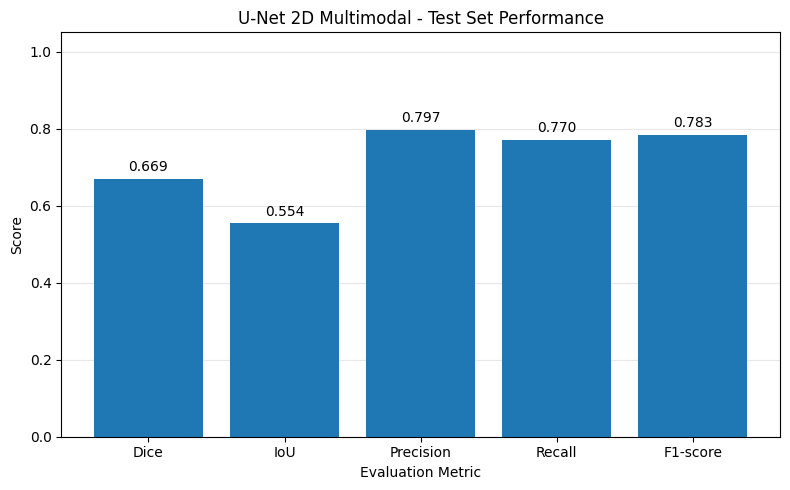

Test metrics plot saved to: /kaggle/working/models/unet2d_multimodal/multimodal/test_metrics.png
🏃 View run MULTIMODAL-2D_Adam_lr5e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f839658b7d7945449f8b8fe0dcc07ea1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
Test metrics plot logged to MLflow.


In [32]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_metrics["Metric"],
    results_metrics["Value"]
)

# Y-axis configuration
plt.ylim(0, 1.05)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.title(
    "U-Net 2D Multimodal - Test Set Performance"
)

# Display metric values above bars
for bar, value in zip(
    bars,
    results_metrics["Value"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

# Grid
plt.grid(
    axis="y",
    alpha=0.3
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

# Save Figure

test_metrics_plot = (
    MULTIMODAL_SAVE_DIR
    / "test_metrics.png"
)

plt.savefig(
    test_metrics_plot,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"Test metrics plot saved to: "
    f"{test_metrics_plot}"
)

# Log Artifact to Best MLflow Run

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        str(test_metrics_plot),
        artifact_path="evaluation"
    )

print(
    "Test metrics plot logged to MLflow."
)

### matrice de confusion

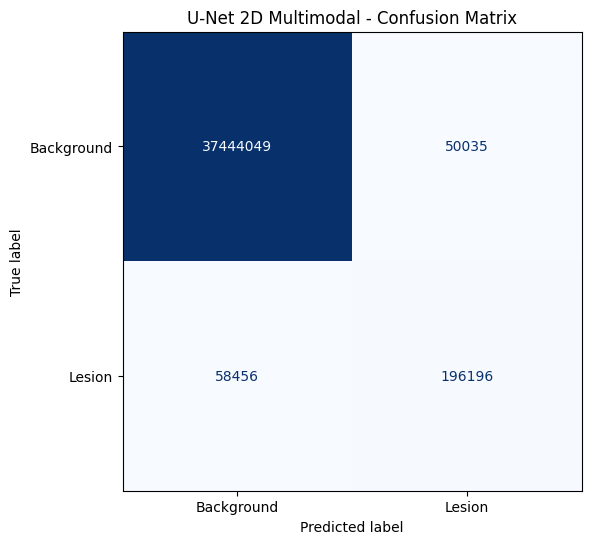

Confusion matrix saved to: /kaggle/working/models/unet2d_multimodal/multimodal/confusion_matrix.png
🏃 View run MULTIMODAL-2D_Adam_lr5e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f839658b7d7945449f8b8fe0dcc07ea1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
Confusion matrix logged to MLflow.


In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

# Compute Confusion Matrix

cm = confusion_matrix(
    all_masks,
    all_preds,
    labels=[0, 1]
)

# Create Figure
fig, ax = plt.subplots(
    figsize=(6, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Background",
        "Lesion"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title(
    "U-Net 2D Multimodal - Confusion Matrix"
)

ax.grid(False)

plt.tight_layout()

# Save Figure
confusion_matrix_path = (
    MULTIMODAL_SAVE_DIR
    / "confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"Confusion matrix saved to: "
    f"{confusion_matrix_path}"
)

# Log Artifact to Best MLflow Run
with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        str(confusion_matrix_path),
        artifact_path="evaluation"
    )

print(
    "Confusion matrix logged to MLflow."
)

### Training Curves

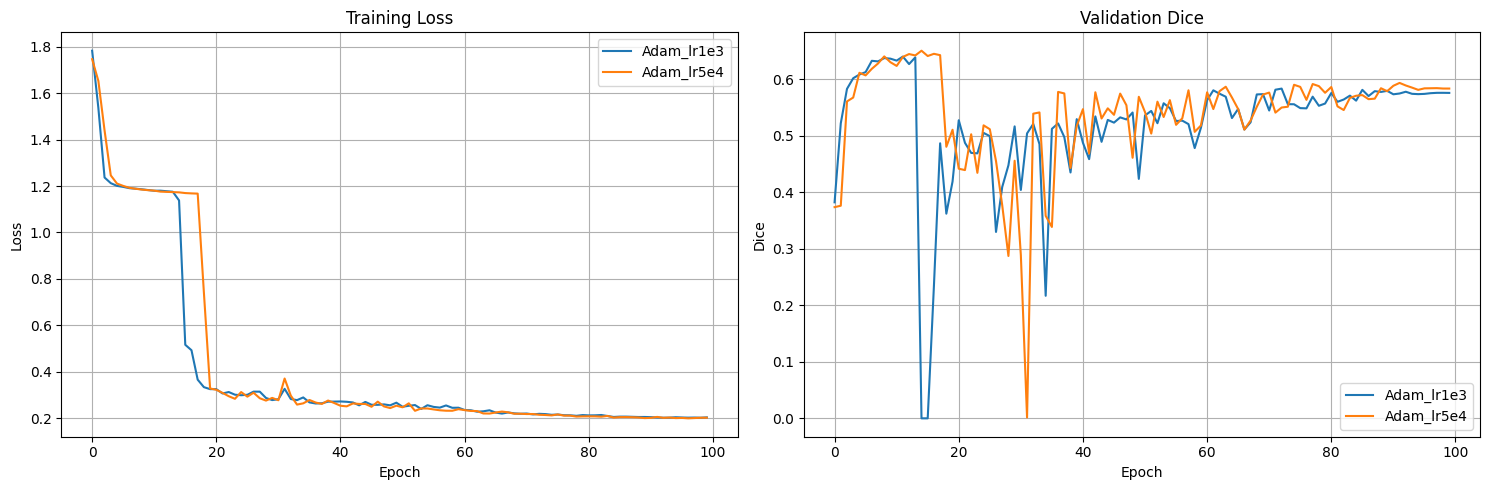

In [34]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)

for exp in results:
    plt.plot(exp["Train Loss"],label=exp["Experiment"])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()

plt.subplot(1,2,2)

for exp in results:
    plt.plot(exp["Validation Dice"],label=exp["Experiment"])

plt.title("Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

### Patient Segmentation Visualization

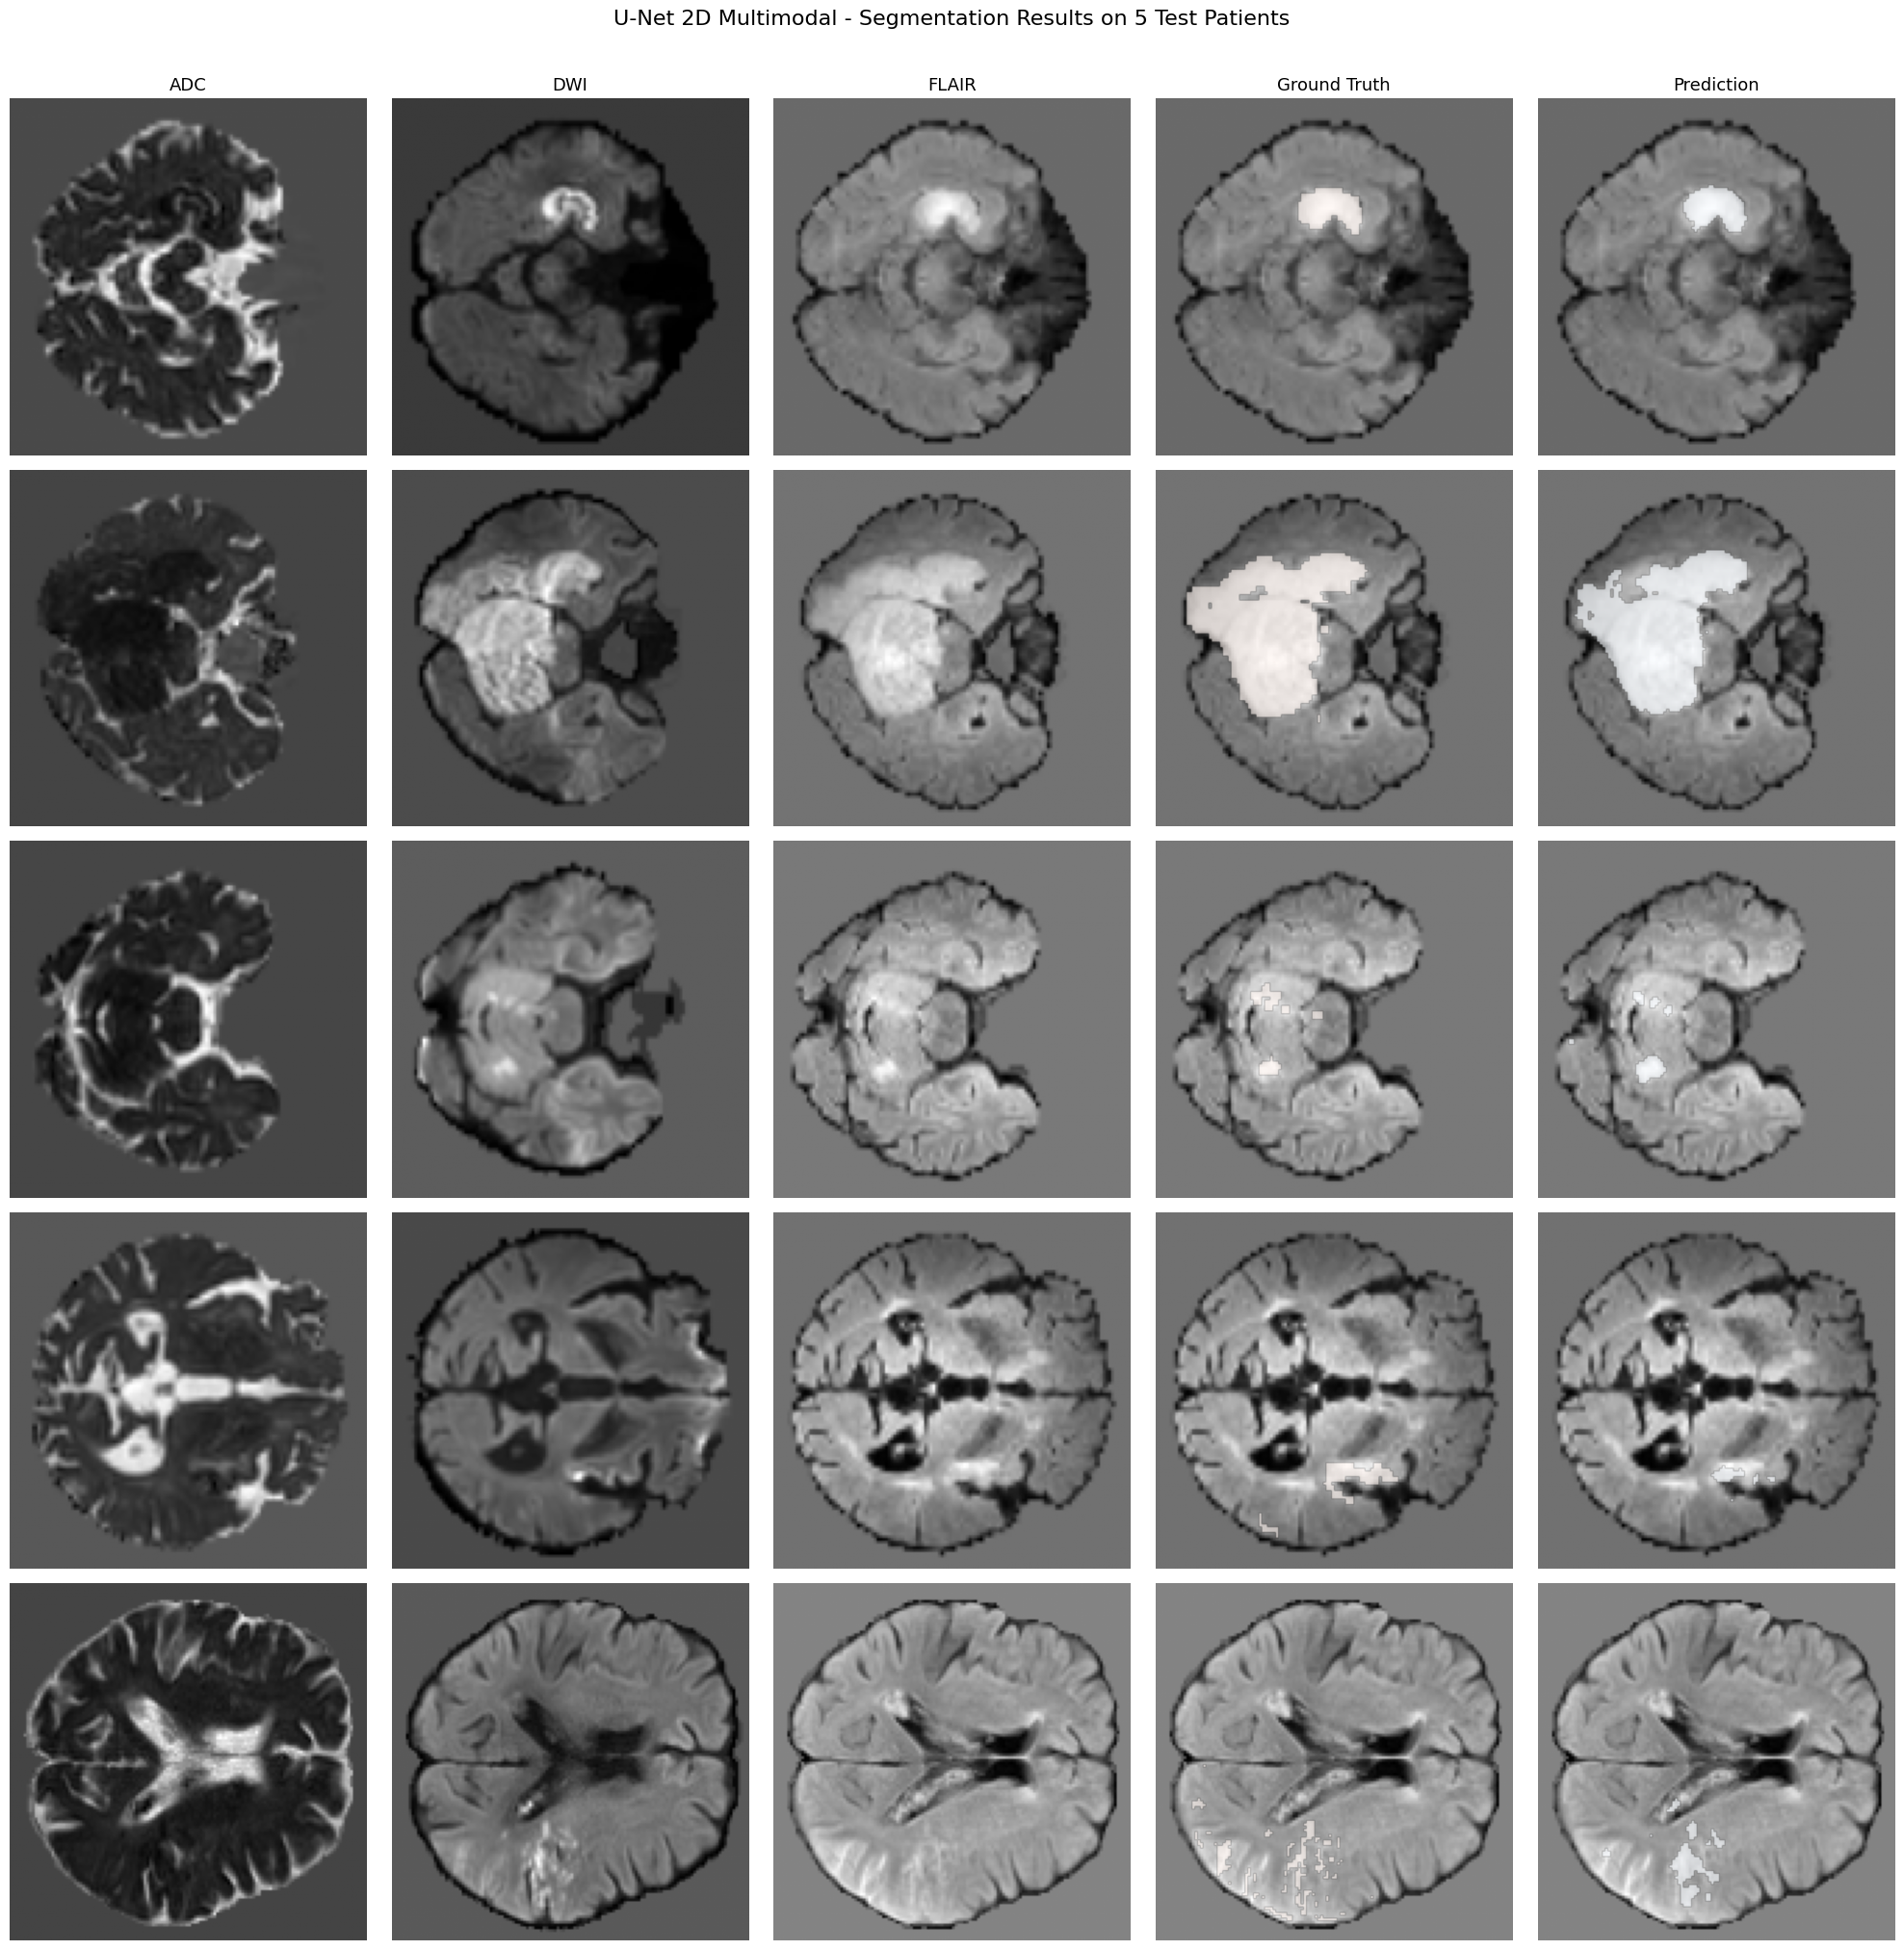

Segmentation visualization saved to: /kaggle/working/models/unet2d_multimodal/multimodal/segmentation_visualization.png
🏃 View run MULTIMODAL-2D_Adam_lr5e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f839658b7d7945449f8b8fe0dcc07ea1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
Segmentation visualization logged to MLflow.


In [35]:
model.eval()

NUM_PATIENTS_TO_SHOW = 5

# Select Test Patients

selected_patients = test_patients[
    :NUM_PATIENTS_TO_SHOW
]

fig, axes = plt.subplots(
    NUM_PATIENTS_TO_SHOW,
    5,
    figsize=(20, 4 * NUM_PATIENTS_TO_SHOW)
)

column_titles = [
    "ADC",
    "DWI",
    "FLAIR",
    "Ground Truth",
    "Prediction"
]

# Process Each Patient

for row, patient_dir in enumerate(
    selected_patients
):

    # --------------------------------------------------------
    # Load Patient Volumes
    # --------------------------------------------------------

    adc = np.load(
        patient_dir / "adc.npy"
    ).astype(np.float32)

    dwi = np.load(
        patient_dir / "dwi.npy"
    ).astype(np.float32)

    flair = np.load(
        patient_dir / "flair.npy"
    ).astype(np.float32)

    mask = np.load(
        patient_dir / "mask.npy"
    ).astype(np.float32)

    lesion_per_slice = mask.sum(
        axis=(0, 1)
    )

    slice_idx = np.argmax(
        lesion_per_slice
    )

    adc_slice = adc[:, :, slice_idx]
    dwi_slice = dwi[:, :, slice_idx]
    flair_slice = flair[:, :, slice_idx]

    gt = mask[:, :, slice_idx]

    def normalize(image):

        mean = image.mean()
        std = image.std()

        if std > 0:
            image = (
                image - mean
            ) / std

        return image

    adc_norm = normalize(adc_slice)
    dwi_norm = normalize(dwi_slice)
    flair_norm = normalize(flair_slice)

    image = np.stack(
        [
            adc_norm,
            dwi_norm,
            flair_norm
        ],
        axis=0
    )

    image = torch.from_numpy(
        image
    ).float().unsqueeze(0).to(DEVICE)

    # Shape:
    # [1, 3, H, W]

    # Model Prediction

    with torch.no_grad():

        output = model(image)

        prediction = (
            torch.sigmoid(output) > 0.5
        ).float()

    prediction = (
        prediction
        .squeeze()
        .cpu()
        .numpy()
    )

    # Visualization
    # ADC
    axes[row, 0].imshow(
        adc_slice,
        cmap="gray"
    )

    # DWI
    axes[row, 1].imshow(
        dwi_slice,
        cmap="gray"
    )

    # FLAIR
    axes[row, 2].imshow(
        flair_slice,
        cmap="gray"
    )

    # Ground Truth
    axes[row, 3].imshow(
        flair_slice,
        cmap="gray"
    )

    axes[row, 3].imshow(
        np.ma.masked_where(
            gt == 0,
            gt
        ),
        cmap="Reds",
        alpha=0.6
    )

    # Prediction
    axes[row, 4].imshow(
        flair_slice,
        cmap="gray"
    )

    axes[row, 4].imshow(
        np.ma.masked_where(
            prediction == 0,
            prediction
        ),
        cmap="Blues",
        alpha=0.6
    )

    # Patient Information
    patient_name = patient_dir.name

    axes[row, 0].set_ylabel(
        f"{patient_name}\nSlice {slice_idx}",
        fontsize=10
    )

    # Remove Axes

    for col in range(5):

        axes[row, col].axis("off")

        if row == 0:

            axes[row, col].set_title(
                column_titles[col],
                fontsize=13
            )

# Final Figure
plt.suptitle(
    "U-Net 2D Multimodal - "
    "Segmentation Results on 5 Test Patients",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

# Save Segmentation Visualization
segmentation_visualization_path = (
    MULTIMODAL_SAVE_DIR
    / "segmentation_visualization.png"
)

plt.savefig(
    segmentation_visualization_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"Segmentation visualization saved to: "
    f"{segmentation_visualization_path}"
)

# Log Artifact to Best MLflow Run

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        str(segmentation_visualization_path),
        artifact_path="predictions"
    )

print(
    "Segmentation visualization logged to MLflow."
)